In [6]:
import warnings
warnings.filterwarnings("ignore")

import mplhep as hep
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import os

import hist
s = hist.tag.Slicer()

from coffea import util

hep.style.use("CMS")

In [1]:
def reweight(myhist, wc, wcval):

    #reads the wc axes of the histogram, labels corresponding to points in WC space
    wcbins = [myhist.axes[myhist.axes.name.index('wc')].bin(i) for i in range(0,myhist.axes[myhist.axes.name.index('wc')].size)]
    
    #builds dictionaries of the WCs, one for each WC
    points = []
    for p in wcbins:
        points.append({})

        for x in p.split(","):
            if "SM" in x:
                points[-1]['c'+x] = 1
            else:
                v = x.split("=")
                points[-1][v[0]] = float(v[1])

    #makes sure that there are enough points to build a quadratic function
    from functools import reduce
    parameters = ["cSM"] + sorted(reduce(set.union, (set(keys) for keys in points), set()))
    npar = len(parameters)
    ntri = npar*(npar+1)//2
    if len(points) < ntri:
        print(f"Have {len(points)} reweight points for {npar} paramteters. Need at least {ntri}")

    coefmap = np.zeros((len(points), ntri))

    #builds a matrix that maps WC points onto a vector corresponding to ci,cj
    for i, point in enumerate(points):
        coefvec = np.zeros(npar)
        # implicit cSM=1
        coefvec[parameters.index("cSM")] = 1.0
        for name, val in point.items():
            coefvec[parameters.index(name)] = val
        coeftri = np.multiply.outer(coefvec, coefvec)[np.tril_indices(npar)]
        coefmap[i] = coeftri

    #solves for quadratic coefficients for each bin
    x, residuals, rank, s = np.linalg.lstsq(coefmap, myhist.values().T, rcond=None)
    scaling = np.zeros((myhist.values().shape[0], npar, npar))
    for k, (i, j) in enumerate(zip(*np.tril_indices(npar))):
        scaling[:, i, j] += x[k] * 0.5
        scaling[:, j, i] += x[k] * 0.5

    def weightfor(coef):
        return np.einsum("i,eij,j->e", coef, scaling, coef)

    coefvec = np.zeros(npar)
    coefvec[parameters.index("cSM")] = 1.0
    coefvec[parameters.index(wc)] = wcval

    return weightfor(coefvec)

In [2]:
#matplotlib.rc('text', usetex=True)
#matplotlib.rc('text.latex', preamble=r'\usepackage{amssymb}')
        
wcstring = {}
wcstring['cHWtil'] = r'$\tilde{c}_{HW}$'
wcstring['cHW'] = r'$c_{HW}$'
wcstring['cHj1'] = r'$c_{Hj1}$'
wcstring['cHj3'] = r'$c_{Hj3}$'
wcstring['cHbox'] = r'$c_{Hbox}$'

In [3]:
def plot_with_ratio(wc, wcval, name, rwin, h1, y0=[], y1=[], y2=[], rebin=1):
    fig, ax = plt.subplots(3,1,sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]}, figsize=(10,12))
    fig.subplots_adjust(hspace=0.1)
    
    var = h1.axes[0].name
    rw = rwin[{var:s[::hist.rebin(rebin)]}]
    direct = h1[{var:s[::hist.rebin(rebin)]}]
    
    bin_width = direct.axes[0].widths[0]
    
    sm = rw[{'wc':'SM'}].values()/(10**6)/bin_width
    sm_err = np.sqrt(rw[{'wc':'SM'}].variances())/(10**6)/bin_width
               
    direct_norm = direct[{'wc':'SM'}].values()/(10**6)/bin_width
    direct_norm_err = np.sqrt(direct[{'wc':'SM'}].variances())/(10**6)/bin_width

    rw_norm = reweight(rw, wc, wcval)/(10**6)/bin_width
    print(rw_norm)
    rw_norm_err = np.sqrt(direct[{'wc':'SM'}].variances())/(10**6)/bin_width
    
    the_bins = rw[{'wc':'SM'}].axes[0].edges
    bin_centers = the_bins[:-1] + 0.5*np.diff(the_bins)
    
    ax[0].hist(the_bins[:-1],
               bins=the_bins,
               weights=sm,
               label='SM',
               histtype='step',
               color='black',
               lw=2
               )  
    ax[0].errorbar(bin_centers, sm, yerr=sm_err, linestyle='',color='black',lw=2)
    
    ax[0].hist(the_bins[:-1],
               bins=the_bins,
               weights=rw_norm,
               label='SM reweighted to '+wcstring[wc]+'='+str(int(wcval)),
               histtype='step',
               color='tab:red',
               lw=2
               )        
    ax[0].errorbar(bin_centers, rw_norm, yerr=rw_norm_err, linestyle='',color='tab:red',lw=2)
    
    ax[0].hist(the_bins[:-1],
               bins=the_bins,
               weights=direct_norm,
               label='Simulated '+wcstring[wc]+'=1',
               histtype='step',
               color='tab:blue',
               lw=2
               )   
    ax[0].errorbar(bin_centers, direct_norm, yerr=direct_norm_err, linestyle='',color='tab:blue',lw=2)
   
    # Ratio panel
    rw_rat = np.divide(rw_norm,sm)#*rw[{'wc':'SM',var:sum}].value
    rw_rat_err = np.divide(rw_norm_err,sm)#*rw[{'wc':'SM',var:sum}].value
    direct_rat = np.divide(direct_norm,sm)#*rw[{'wc':'SM',var:sum}].value
    direct_rat_err = np.divide(direct_norm_err,sm)#*rw[{'wc':'SM',var:sum}].value
        
    ax[1].hist(the_bins[:-1],
               bins=the_bins,
               weights=np.ones(len(the_bins)-1),
               histtype='step',
               color='black',
               lw=2)
        
    ax[1].hist(the_bins[:-1],
               bins=the_bins,
               weights=rw_rat,
               histtype='step',color='tab:red',
               lw=2
               )        
    ax[1].errorbar(bin_centers, rw_rat, yerr=rw_rat_err, linestyle='',color='tab:red',lw=2)
        
    ax[1].hist(the_bins[:-1],
               bins=the_bins,
               weights=direct_rat,
               histtype='step',
               color='tab:blue',
               lw=2
               )   
    ax[1].errorbar(bin_centers, direct_rat, yerr=direct_rat_err, linestyle='',color='tab:blue',lw=2)
    
    # Second ratio panel
    rw_rat2 = np.divide(rw_norm,direct_norm)#*rw[{'wc':'SM',var:sum}].value
    rw_rat2_err = np.divide(rw_norm_err,direct_norm)#*rw[{'wc':'SM',var:sum}].value
        
    ax[2].hist(the_bins[:-1],
               bins=the_bins,
               weights=np.ones(len(the_bins)-1),
               histtype='step',
               color='tab:blue',
               lw=2)
    ax[2].errorbar(bin_centers, rw_rat2, yerr=rw_rat2_err, linestyle='',color='tab:red',lw=2)
        
    ax[2].hist(the_bins[:-1],
               bins=the_bins,
               weights=rw_rat2,
               histtype='step',
               color='tab:red',
               lw=2
               )        
    #ax[2].errorbar(bin_centers, rw_rat2, yerr=rw_rat2_err, linestyle='',color='tab:red',lw=2)

    ax[0].set_ylabel(name,fontsize=24)
    if 'GeV' in h1.axes[0].label:
        ax[0].set_yscale('log')
        ax[0].set_xlim(0,700)
    elif 'eta' in h1.axes[0].label:
        ax[0].set_xlim(-6,6)
    elif 'phi' in h1.axes[0].label:
        ax[0].set_xlim(-3.14,3.14)
            
    textstr = 'VBF H'
    ax[0].text(0.02, 1.07, textstr, transform=ax[0].transAxes, fontsize=24,
        verticalalignment='top', weight="bold")
        
    ax[1].set_ylabel('Ratio to\nSM',fontsize=24,multialignment='center')
    #ax[1].set_ylim(0.5,2)
    ax[2].set_ylabel('Ratio to\nsim. '+wcstring[wc]+'='+str(int(wcval)),fontsize=24,multialignment='center')
    ax[2].set_xlabel(h1.axes[0].label,fontsize=24)
    
    if len(y0) == 2:
        ax[0].set_ylim(y0)
    if len(y1) == 2:
        ax[1].set_ylim(y1)
    if len(y2) == 2:
        ax[2].set_ylim(y2)
    
    fig.legend(frameon=False, fontsize=20, bbox_to_anchor=(0.9,0.88))
    
    #plotdir = "noteplots/"+wc+"/"
    #if not os.path.exists(plotdir):
    #    os.mkdir(plotdir)
    #fig.savefig(plotdir+"overlay_"+var+"_"+wc+str(wcval)+".png",bbox_inches='tight')
    #fig.savefig(plotdir+"overlay_"+var+"_"+wc+str(wcval)+".pdf",bbox_inches='tight')
    

In [16]:
rw = util.load("coffea/start1.coffea")
direct = util.load("coffea/cHW_sample.coffea")

Have 276 reweight points for 24 paramteters. Need at least 300
[-0.18010066 -0.26367086 -0.19836025  0.02612532  0.06812621  0.10043185
  0.09966262  0.09379971  0.0776927   0.06632621  0.05708049  0.04796494
  0.05364433  0.03601951  0.02472876  0.02478553  0.01606368  0.01616625
  0.02207186  0.00588318]


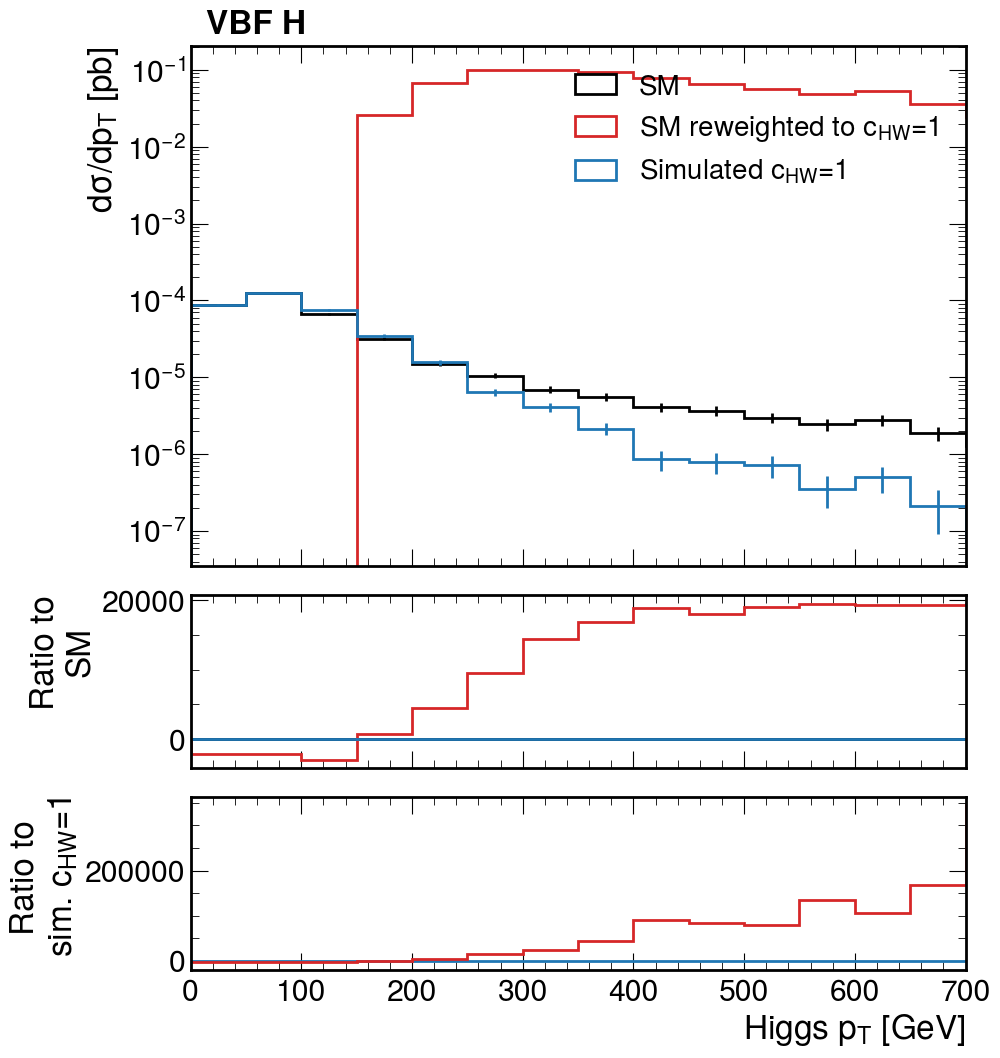

In [17]:
var='hpt'
name=r'$d\sigma / dp_{T}$ [pb]'
    
h0 = rw[var]
h1 = direct[var]

plot_with_ratio('cHW', 1, name, h0, h1, rebin=10)

Have 276 reweight points for 24 paramteters. Need at least 300
[1.07111796 0.85956892 0.77926137 0.66263704 0.73261522 0.86478899
 1.06211372 1.28572832 1.46432871 1.5175832  1.55614309 1.47360137
 1.29760623 1.11624553 0.88411734 0.70499783 0.65385541 0.6934466
 0.99126875 0.99520144]


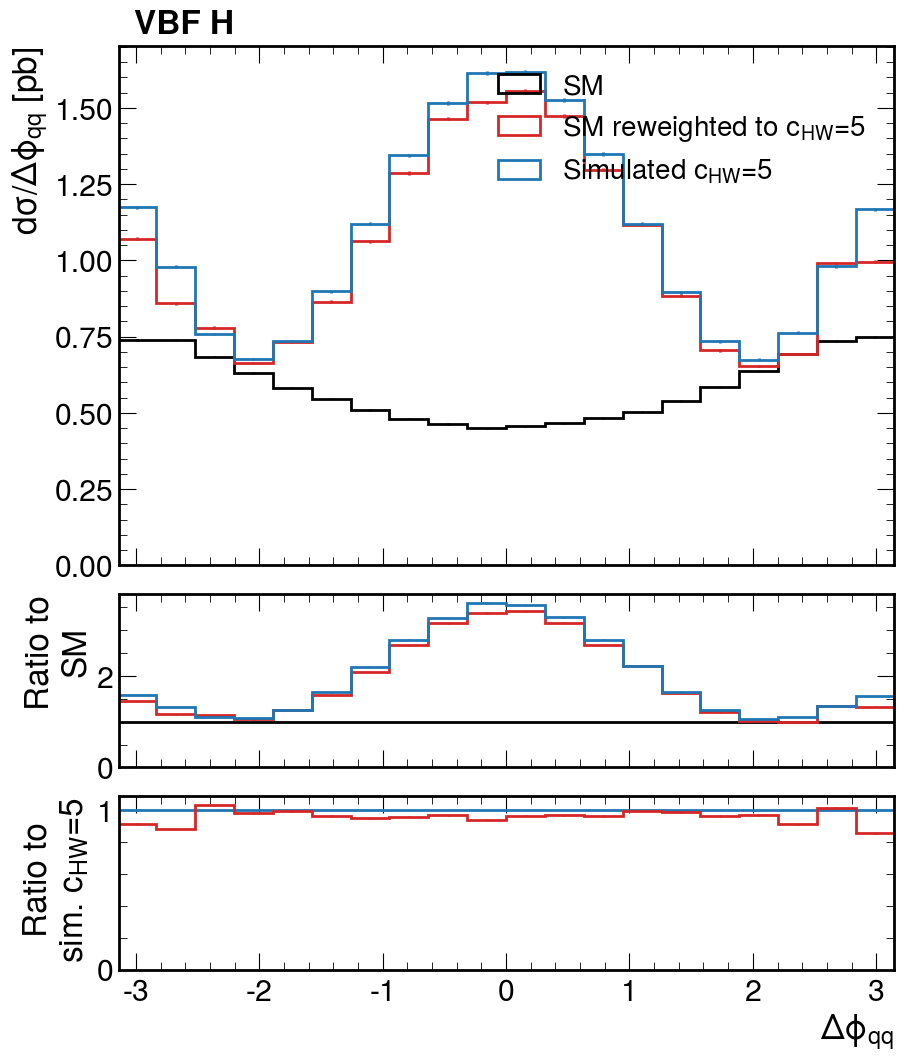

In [10]:
var='dphiqq'
name=r'$d\sigma / \Delta\phi_{qq}$ [pb]'
 
h0 = rw[var]
h1 = direct[var]

plot_with_ratio('cHW', 5, name, h0, h1, rebin=10)

Have 276 reweight points for 24 paramteters. Need at least 300
[0.36788348 0.47243961 0.56901532 0.61495865 0.6163259  0.57108624
 0.51207873 0.42356044 0.40567833 0.27097294 0.24486947 0.36775842
 0.421256   0.50101809 0.60646155 0.63484868 0.62230621 0.56299751
 0.47401792 0.37011229]


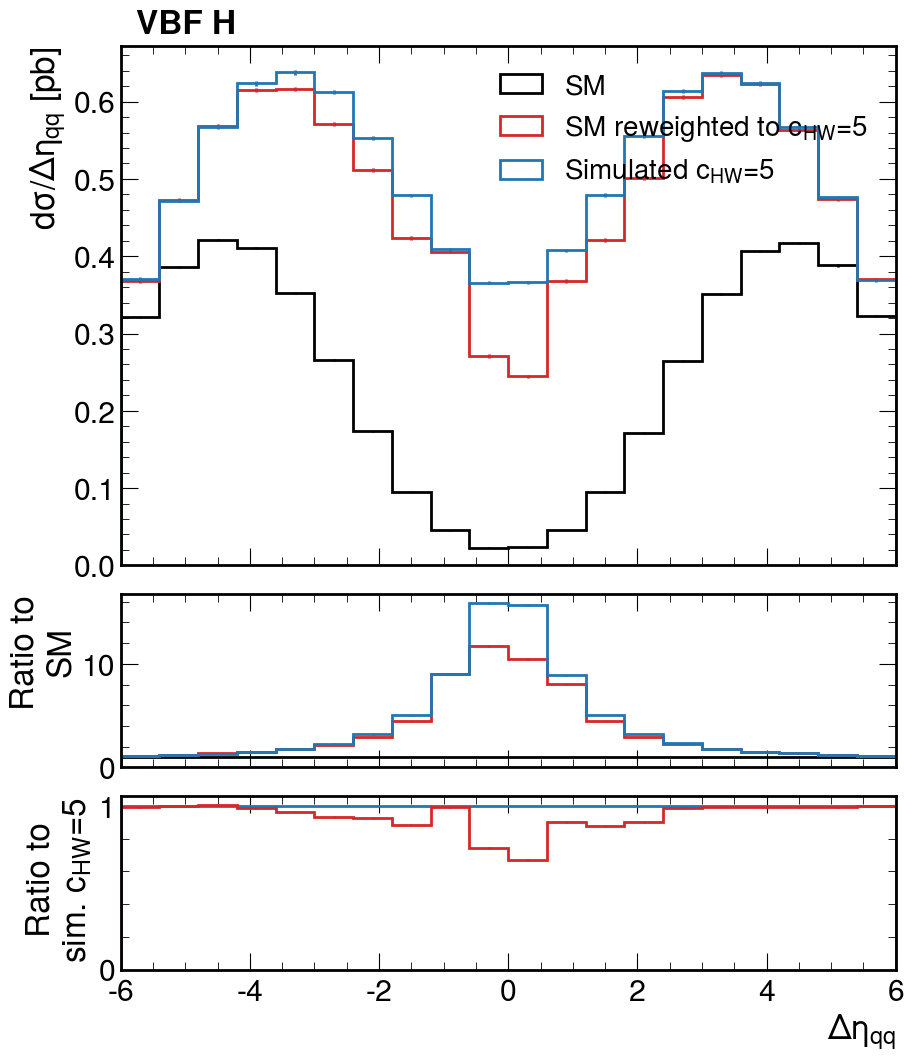

In [11]:
var='detaqq'
name=r'$d\sigma / \Delta\eta_{qq}$ [pb]'
    
h0 = rw[var]
h1 = direct[var]

plot_with_ratio('cHW', 5, name, h0, h1, rebin=10)